<a href="https://colab.research.google.com/github/deluxDeepak/BikeRecommendation_Syststem/blob/main/BikeGenAi_submit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart Bike Recommender System

This project creates a helpful system that recommends bikes to people based on what they like. We do this by:

*   **Getting and cleaning bike data:** Making sure our information about bikes is correct and ready to use.
*   **Looking for patterns:** Exploring the data to understand different bike features and how they relate.
*   **Organizing bikes into groups:** Using a technique called K-Means clustering to put similar bikes together.
*   **Giving personalized suggestions:** When you tell us your preferences (like budget, year, or how much you ride), our system looks at the bike groups and uses a 'content-based' method to find the best matches just for you.

In [62]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading and Initial Inspection

First, we'll load the dataset and perform an initial inspection to understand its structure, data types, and basic statistics.

In [63]:
df = pd.read_csv('https://raw.githubusercontent.com/YBIFoundation/Dataset/main/Bike%20Prices.csv')

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Brand              1061 non-null   object 
 1   Model              1061 non-null   object 
 2   Selling_Price      1061 non-null   int64  
 3   Year               1061 non-null   int64  
 4   Seller_Type        1061 non-null   object 
 5   Owner              1061 non-null   object 
 6   KM_Driven          1061 non-null   int64  
 7   Ex_Showroom_Price  626 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 66.4+ KB


In [65]:
df.describe()

,Selling_Price,Year,KM_Driven,Ex_Showroom_Price
count,1061.000000,1061.000000,1061.000000,6.260000e+02
mean,59638.151744,2013.867107,34359.833176,8.795871e+04
std,56304.291973,4.301191,51623.152702,7.749659e+04
min,5000.000000,1988.000000,350.000000,3.049000e+04
25%,28000.000000,2011.000000,13500.000000,5.485200e+04
50%,45000.000000,2015.000000,25000.000000,7.275250e+04
75%,70000.000000,2017.000000,43000.000000,8.703150e+04
max,760000.000000,2020.000000,880000.000000,1.278000e+06


In [66]:
df.head()

,Brand,Model,Selling_Price,Year,Seller_Type,Owner,KM_Driven,Ex_Showroom_Price
0,TVS,TVS XL 100,30000,2017,Individual,1st owner,8000,30490.0
1,Bajaj,Bajaj ct 100,18000,2017,Individual,1st owner,35000,32000.0
2,Yo,Yo Style,20000,2011,Individual,1st owner,10000,37675.0
3,Bajaj,Bajaj Discover 100,25000,2010,Individual,1st owner,43000,42859.0
4,Bajaj,Bajaj Discover 100,24999,2012,Individual,2nd owner,35000,42859.0


## 2. Data Cleaning

In this section, we handle missing values and duplicate entries to ensure data quality for subsequent analysis and modeling.

In [67]:
df=df.dropna()

In [68]:
# Remove the duplicates
df=df.drop_duplicates()

In [69]:
budget = 30000
recommended = df[df['Selling_Price'] <= budget]
recommended.head()

,Brand,Model,Selling_Price,Year,Seller_Type,Owner,KM_Driven,Ex_Showroom_Price
0,TVS,TVS XL 100,30000,2017,Individual,1st owner,8000,30490.0
1,Bajaj,Bajaj ct 100,18000,2017,Individual,1st owner,35000,32000.0
2,Yo,Yo Style,20000,2011,Individual,1st owner,10000,37675.0
3,Bajaj,Bajaj Discover 100,25000,2010,Individual,1st owner,43000,42859.0
4,Bajaj,Bajaj Discover 100,24999,2012,Individual,2nd owner,35000,42859.0


In [70]:
recommended = df[
    (df['Selling_Price'] <= 30000) &
    (df['Year'] >= 2015) &
    (df['KM_Driven'] <= 40000)
]

recommended.head()

,Brand,Model,Selling_Price,Year,Seller_Type,Owner,KM_Driven,Ex_Showroom_Price
0,TVS,TVS XL 100,30000,2017,Individual,1st owner,8000,30490.0
1,Bajaj,Bajaj ct 100,18000,2017,Individual,1st owner,35000,32000.0
14,Honda,Honda Navi [2016-2017],26000,2016,Individual,1st owner,17450,44389.0
16,Honda,Honda Navi [2016-2017],23000,2016,Individual,1st owner,17450,44389.0
23,Bajaj,Bajaj Discover 100,27000,2015,Individual,1st owner,21000,47000.0


In [71]:
display(recommended.head()) # Display the filtered recommendations

,Brand,Model,Selling_Price,Year,Seller_Type,Owner,KM_Driven,Ex_Showroom_Price
0,TVS,TVS XL 100,30000,2017,Individual,1st owner,8000,30490.0
1,Bajaj,Bajaj ct 100,18000,2017,Individual,1st owner,35000,32000.0
14,Honda,Honda Navi [2016-2017],26000,2016,Individual,1st owner,17450,44389.0
16,Honda,Honda Navi [2016-2017],23000,2016,Individual,1st owner,17450,44389.0
23,Bajaj,Bajaj Discover 100,27000,2015,Individual,1st owner,21000,47000.0


In [72]:
budget = int(input("Enter your budget: "))
year = int(input("Minimum year: "))
km_limit = int(input("Maximum KM Driven: "))

Enter your budget: 30000
Minimum year: 2015
Maximum KM Driven: 3000


In [73]:
recommended = df[
    (df['Selling_Price'] <= budget) &
    (df['Year'] >= year) &
    (df['KM_Driven'] <= km_limit)
]

In [74]:
# Added sorting
recommended = recommended.sort_values(
    by=['Year', 'KM_Driven'],
    ascending=[False, True]
)

## 4. Exploratory Data Analysis (EDA)

In this section, we perform EDA to understand the data distribution and relationships between variables. We start by visualizing the distribution of `Selling_Price`.

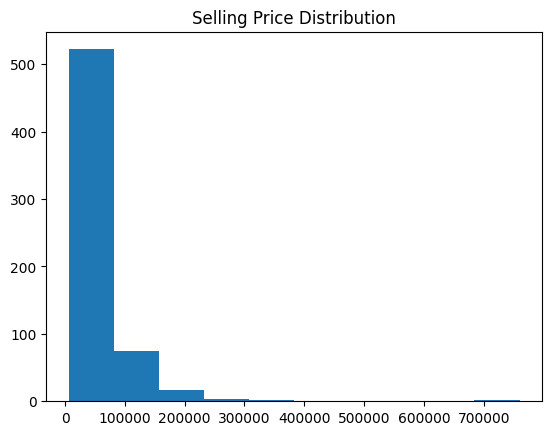

In [75]:
plt.hist(df['Selling_Price'])
plt.title("Selling Price Distribution")
plt.show()

### Exploring Categorical Features and Selling Price

Let's visualize how `Selling_Price` varies across different categorical features like `Brand`, `Seller_Type`, and `Owner`.

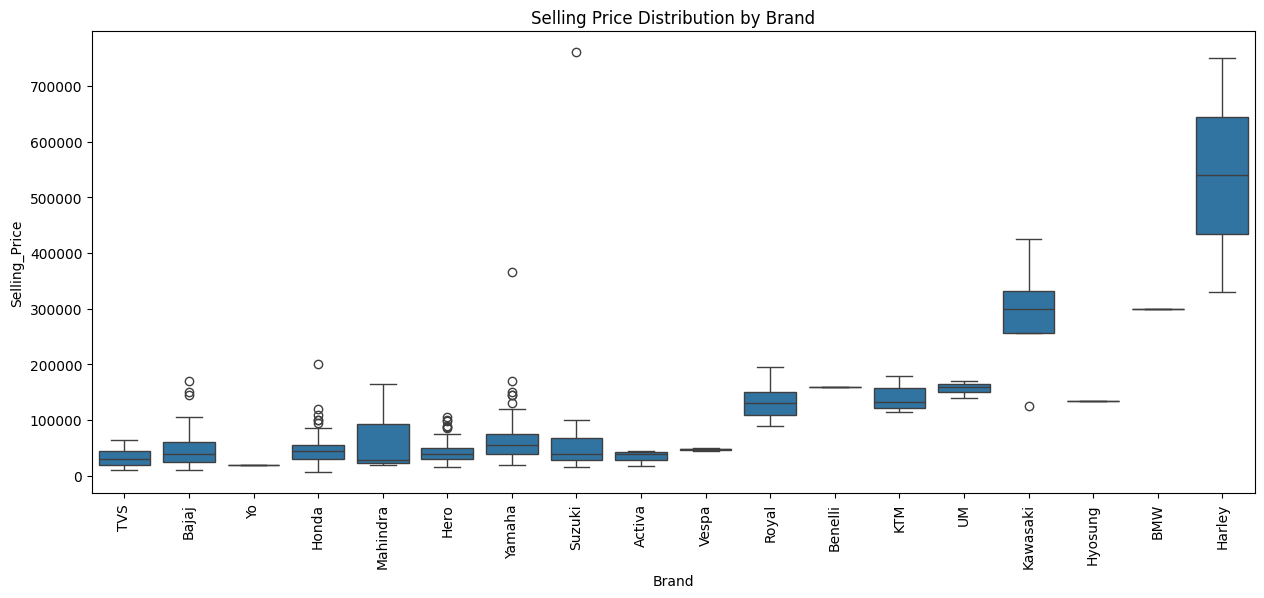

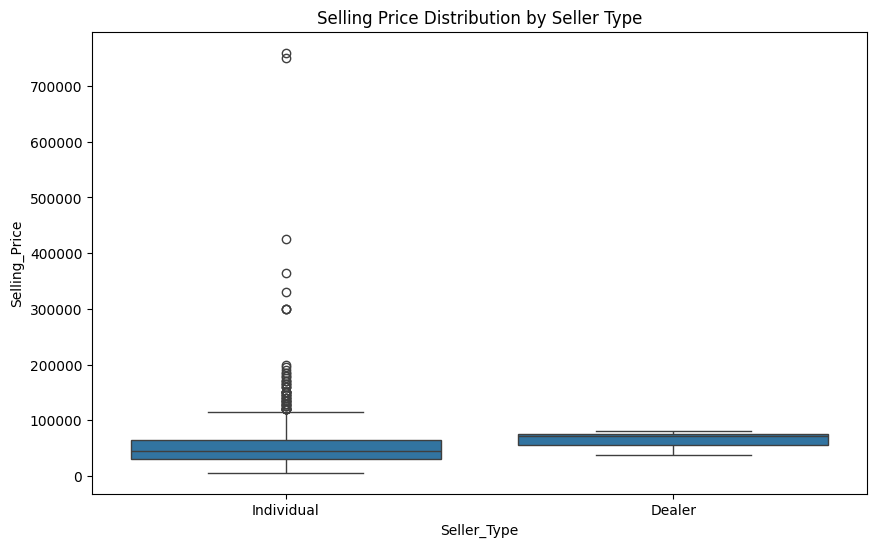

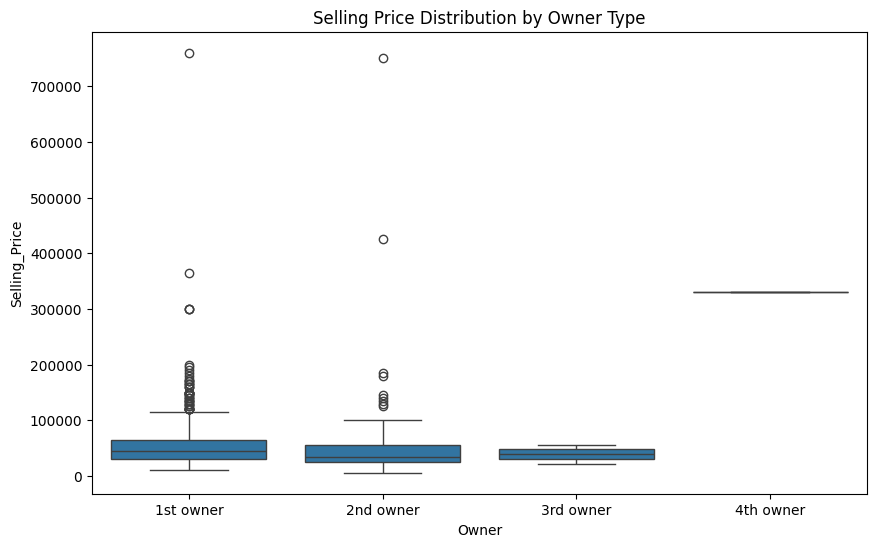

In [76]:
plt.figure(figsize=(15, 6))
sns.boxplot(x='Brand', y='Selling_Price', data=df)
plt.xticks(rotation=90)
plt.title('Selling Price Distribution by Brand')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='Seller_Type', y='Selling_Price', data=df)
plt.title('Selling Price Distribution by Seller Type')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='Owner', y='Selling_Price', data=df)
plt.title('Selling Price Distribution by Owner Type')
plt.show()

## 5. Feature Engineering: Encoding Categorical Features

To prepare our data for machine learning algorithms, we'll convert categorical features into numerical representations using one-hot encoding. This creates new binary columns for each category.

In [77]:
categorical_cols = ['Brand', 'Model', 'Seller_Type', 'Owner']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Original DataFrame shape:", df.shape)
print("Encoded DataFrame shape:", df_encoded.shape)
display(df_encoded.head())

Original DataFrame shape: (622, 8)
Encoded DataFrame shape: (622, 207)


,Selling_Price,Year,KM_Driven,Ex_Showroom_Price,Brand_BMW,Brand_Bajaj,Brand_Benelli,Brand_Harley,Brand_Hero,Brand_Honda,...,Model_Yamaha YBR 125,Model_Yamaha YZF R15 S,Model_Yamaha YZF R15 V3,Model_Yamaha YZF R15 [2011-2018],Model_Yamaha YZF R3,Model_Yo Style,Seller_Type_Individual,Owner_2nd owner,Owner_3rd owner,Owner_4th owner
0,30000,2017,8000,30490.0,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,18000,2017,35000,32000.0,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,20000,2011,10000,37675.0,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
3,25000,2010,43000,42859.0,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,24999,2012,35000,42859.0,False,True,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False


### 6.1. Prepare Features for Clustering

We select the numerical and one-hot encoded categorical features and scale them using `StandardScaler`. This ensures that all features contribute equally to the clustering process, preventing features with larger magnitudes from dominating.

In [78]:
from sklearn.preprocessing import StandardScaler

# Create an instance of StandardScaler
scaler = StandardScaler()

# Apply the scaler's fit_transform method to the entire df_encoded DataFrame
df_scaled_array = scaler.fit_transform(df_encoded)

# Convert the scaled data back into a Pandas DataFrame, retaining original column names
df_scaled = pd.DataFrame(df_scaled_array, columns=df_encoded.columns)

print("Scaled DataFrame shape:", df_scaled.shape)
display(df_scaled.head())

Scaled DataFrame shape: (622, 207)


,Selling_Price,Year,KM_Driven,Ex_Showroom_Price,Brand_BMW,Brand_Bajaj,Brand_Benelli,Brand_Harley,Brand_Hero,Brand_Honda,...,Model_Yamaha YBR 125,Model_Yamaha YZF R15 S,Model_Yamaha YZF R15 V3,Model_Yamaha YZF R15 [2011-2018],Model_Yamaha YZF R3,Model_Yo Style,Seller_Type_Individual,Owner_2nd owner,Owner_3rd owner,Owner_4th owner
0,-0.492697,0.725617,-0.538323,-0.741292,-0.040129,-0.543906,-0.040129,-0.056796,-0.455815,-0.608312,...,-0.056796,-0.098693,-0.040129,-0.090021,-0.040129,-0.040129,0.069617,-0.344536,-0.069617,-0.040129
1,-0.692673,0.725617,0.055344,-0.721849,-0.040129,1.838554,-0.040129,-0.056796,-0.455815,-0.608312,...,-0.056796,-0.098693,-0.040129,-0.090021,-0.040129,-0.040129,0.069617,-0.344536,-0.069617,-0.040129
2,-0.659344,-1.268495,-0.494347,-0.648777,-0.040129,-0.543906,-0.040129,-0.056796,-0.455815,-0.608312,...,-0.056796,-0.098693,-0.040129,-0.090021,-0.040129,24.919872,0.069617,-0.344536,-0.069617,-0.040129
3,-0.576021,-1.600847,0.231245,-0.582026,-0.040129,1.838554,-0.040129,-0.056796,-0.455815,-0.608312,...,-0.056796,-0.098693,-0.040129,-0.090021,-0.040129,-0.040129,0.069617,-0.344536,-0.069617,-0.040129
4,-0.576037,-0.936143,0.055344,-0.582026,-0.040129,1.838554,-0.040129,-0.056796,-0.455815,-0.608312,...,-0.056796,-0.098693,-0.040129,-0.090021,-0.040129,-0.040129,0.069617,2.902455,-0.069617,-0.040129


### 6.2. Finding the Best Number of Groups (Elbow Method)

To organize our bikes into the best number of groups for K-Means clustering, we use something called the 'Elbow Method'. Here's how it works:

*   We try different numbers of groups (K).
*   For each K, we measure how "tight" the groups are (this is called 'inertia').
*   We then plot these measurements.
*   We look for a point on the graph that looks like an 'elbow' – where the line suddenly stops dropping sharply. This 'elbow' usually tells us the best number of groups to use.

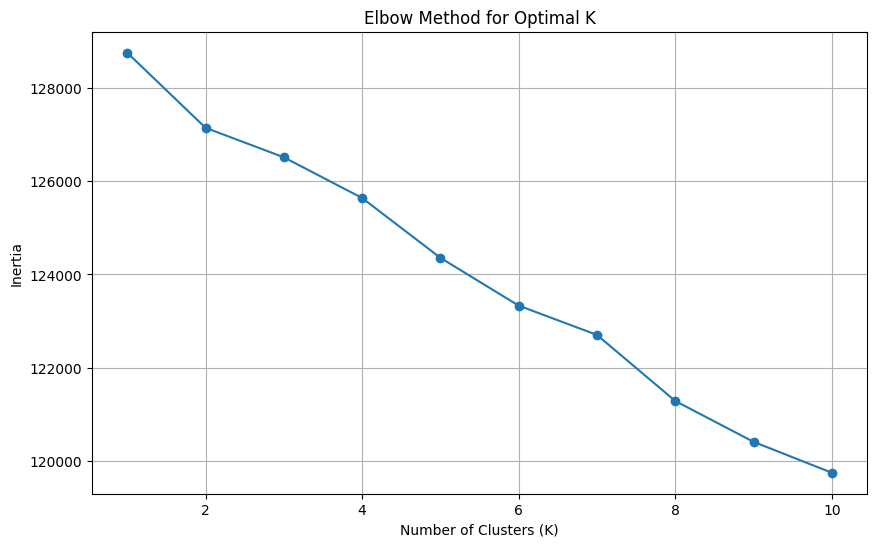

In [79]:
from sklearn.cluster import KMeans

# Calculate inertia for a range of cluster numbers
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10) # Added n_init to suppress warning
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

### 6.3. Grouping Bikes with K-Means

Now that we know the best number of groups (let's say 3, based on our 'Elbow Method' chart), we can use K-Means clustering to actually create these groups:

*   We tell K-Means to find our chosen number of groups (e.g., 3) in our prepared bike data.
*   K-Means then assigns each bike to one of these groups.
*   Finally, we add these group labels (like 'Group 0', 'Group 1', 'Group 2') as a new column called 'Cluster' in our data. This helps us see which bikes belong to which group.

In [80]:
n_clusters = 3  # Choose the optimal number of clusters based on the Elbow Method
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_encoded['Cluster'] = kmeans.fit_predict(df_scaled)

print(f"Number of items per cluster:\n{df_encoded['Cluster'].value_counts()}")
display(df_encoded.head())

Number of items per cluster:
Cluster
1    619
0      2
2      1
Name: count, dtype: int64


,Selling_Price,Year,KM_Driven,Ex_Showroom_Price,Brand_BMW,Brand_Bajaj,Brand_Benelli,Brand_Harley,Brand_Hero,Brand_Honda,...,Model_Yamaha YZF R15 S,Model_Yamaha YZF R15 V3,Model_Yamaha YZF R15 [2011-2018],Model_Yamaha YZF R3,Model_Yo Style,Seller_Type_Individual,Owner_2nd owner,Owner_3rd owner,Owner_4th owner,Cluster
0,30000,2017,8000,30490.0,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,1
1,18000,2017,35000,32000.0,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,1
2,20000,2011,10000,37675.0,False,False,False,False,False,False,...,False,False,False,False,True,True,False,False,False,1
3,25000,2010,43000,42859.0,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,1
4,24999,2012,35000,42859.0,False,True,False,False,False,False,...,False,False,False,False,False,True,True,False,False,1


### 6.4. Analyze and Visualize Clusters

To understand the characteristics of each cluster, we analyze the mean values of the original numerical features for each cluster. This helps us interpret what kind of bikes belong to which cluster.

In [81]:
cluster_summary = df_encoded.groupby('Cluster')[['Selling_Price', 'Year', 'KM_Driven', 'Ex_Showroom_Price']].mean()
print("Cluster Summary (Mean values of numerical features):\n")
display(cluster_summary)

Cluster Summary (Mean values of numerical features):



,Selling_Price,Year,KM_Driven,Ex_Showroom_Price
Cluster,,,,
0,62500.000000,2015.500000,27750.00000,120000.000000
1,59119.019386,2014.815832,32540.23748,87237.179321
2,330000.000000,2014.000000,6500.00000,534000.000000


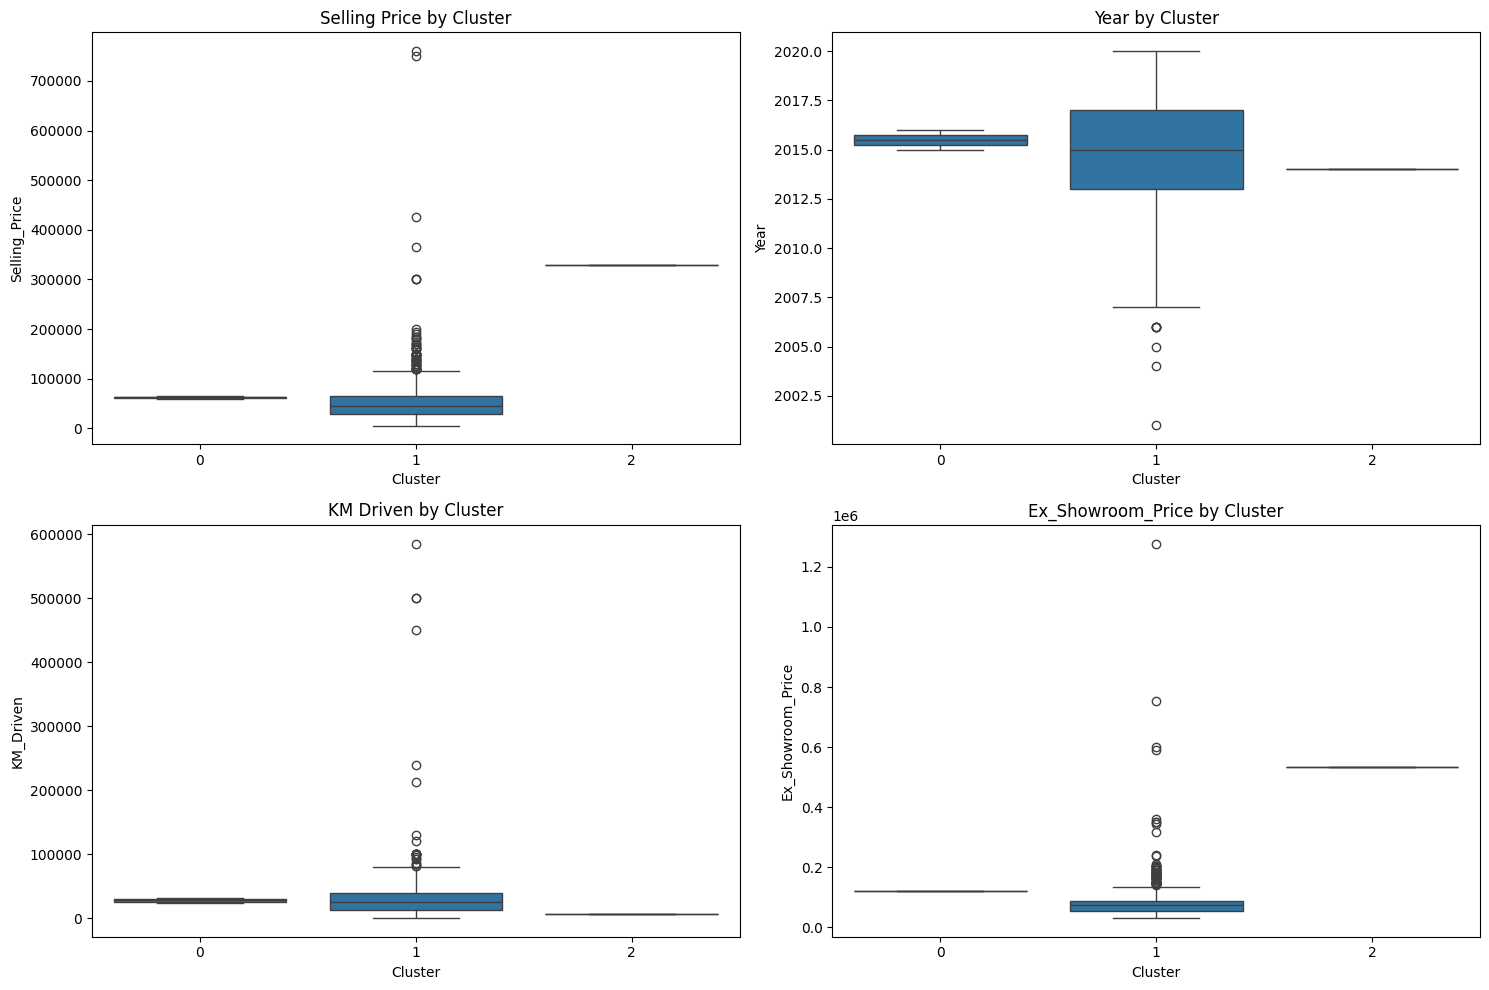

Visualizations of numerical feature distributions across clusters generated.


In [82]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.boxplot(x='Cluster', y='Selling_Price', data=df_encoded)
plt.title('Selling Price by Cluster')

plt.subplot(2, 2, 2)
sns.boxplot(x='Cluster', y='Year', data=df_encoded)
plt.title('Year by Cluster')

plt.subplot(2, 2, 3)
sns.boxplot(x='Cluster', y='KM_Driven', data=df_encoded)
plt.title('KM Driven by Cluster')

plt.subplot(2, 2, 4)
sns.boxplot(x='Cluster', y='Ex_Showroom_Price', data=df_encoded)
plt.title('Ex_Showroom_Price by Cluster')

plt.tight_layout()
plt.show()

print("Visualizations of numerical feature distributions across clusters generated.")

## 7. Recommendation Logic with Clustering and Content-Based Filtering

Now that we have identified clusters, we can use them to build a more intelligent recommendation system. First, we add the `Cluster` labels back to the original `df` DataFrame to maintain readability with original features.

In [83]:
df['Cluster'] = df_encoded['Cluster']
print("Added 'Cluster' column to original DataFrame.")
display(df.head())

Added 'Cluster' column to original DataFrame.


,Brand,Model,Selling_Price,Year,Seller_Type,Owner,KM_Driven,Ex_Showroom_Price,Cluster
0,TVS,TVS XL 100,30000,2017,Individual,1st owner,8000,30490.0,1
1,Bajaj,Bajaj ct 100,18000,2017,Individual,1st owner,35000,32000.0,1
2,Yo,Yo Style,20000,2011,Individual,1st owner,10000,37675.0,1
3,Bajaj,Bajaj Discover 100,25000,2010,Individual,1st owner,43000,42859.0,1
4,Bajaj,Bajaj Discover 100,24999,2012,Individual,2nd owner,35000,42859.0,1


### 7.1. Enhanced Recommendation Function

This function helps find bikes you might like by:

*   **Finding initial matches:** It first looks for bikes that strictly fit your budget, minimum year, and maximum kilometers driven.
*   **Broadening the search (if needed):** If no bikes are found with your strict choices, it relaxes the rules a bit and suggests bikes from the most common group (cluster) that still somewhat fit your budget and other preferences.
*   **Scoring bikes for you:** It gives each bike a 'Preference Score' based on how well it matches what you asked for. Bikes that are closer to your ideal get a higher score.
*   **Showing the best options:** Finally, it sorts the recommended bikes by their 'Preference Score' to show you the top choices first.

In [84]:
import numpy as np

# Recommendation Logic here

def get_recommendations(df, budget, min_year, max_km):
    initial_recommendations = df[
        (df['Selling_Price'] <= budget) &
        (df['Year'] >= min_year) &
        (df['KM_Driven'] <= max_km)
    ]

    if initial_recommendations.empty:
        print("No bikes found matching your strict criteria. Trying to broaden the search.")
        dominant_cluster = df['Cluster'].value_counts().idxmax()
        print(f"Recommending from the dominant cluster (Cluster {dominant_cluster}) with relaxed criteria.")

        recommendations = df[
            (df['Cluster'] == dominant_cluster) &
            (df['Selling_Price'] <= budget * 1.2) &
            (df['Year'] >= min_year - 2) &
            (df['KM_Driven'] <= max_km * 1.5)
        ].copy()
    else:
        present_clusters = initial_recommendations['Cluster'].unique()

        recommendations = df[
            (df['Cluster'].isin(present_clusters)) &
            (df['Selling_Price'] <= budget) &
            (df['Year'] >= min_year) &
            (df['KM_Driven'] <= max_km)
        ].copy()

    if not recommendations.empty:
        epsilon = 1e-6

        max_selling_price_diff = df['Selling_Price'].max() - df['Selling_Price'].min()
        max_year_diff = df['Year'].max() - df['Year'].min()
        max_km_diff = df['KM_Driven'].max() - df['KM_Driven'].min()

        recommendations.loc[:, 'price_score'] = (budget - recommendations['Selling_Price']) / (max_selling_price_diff + epsilon)
        recommendations.loc[:, 'year_score'] = (recommendations['Year'] - min_year) / (max_year_diff + epsilon)
        recommendations.loc[:, 'km_score'] = (max_km - recommendations['KM_Driven']) / (max_km_diff + epsilon)

        recommendations.loc[:, 'Preference_Score'] = recommendations['price_score'].clip(lower=0) + \
                                             recommendations['year_score'].clip(lower=0) + \
                                             recommendations['km_score'].clip(lower=0)

        recommendations = recommendations.sort_values(by=['Preference_Score', 'Year', 'KM_Driven', 'Selling_Price'],
                                                      ascending=[False, False, True, True])

        recommendations = recommendations.drop(columns=['price_score', 'year_score', 'km_score', 'Preference_Score'])

    return recommendations.drop_duplicates(subset=['Brand', 'Model', 'Selling_Price']).reset_index(drop=True)

try:
    user_budget = int(input("Enter your maximum budget (e.g., 50000): "))
    user_min_year = int(input("Enter your minimum preferred manufacturing year (e.g., 2015): "))
    user_max_km = int(input("Enter your maximum preferred KM Driven (e.g., 40000): "))
except ValueError:
    print("Invalid input. Please enter numerical values.")
    user_budget = 50000
    user_min_year = 2015
    user_max_km = 40000
    print(f"Using default values: Budget={user_budget}, Min Year={user_min_year}, Max KM={user_max_km}")

final_recommendations = get_recommendations(df, user_budget, user_min_year, user_max_km)

print("\n--- Your Recommended Bikes ---")
if not final_recommendations.empty:
    for index, row in final_recommendations.head(10).iterrows():
        print(f"Brand: {row['Brand']}, Model: {row['Model']}, Price: \u20b9{row['Selling_Price']}, Year: {row['Year']}, KM Driven: {row['KM_Driven']}, Cluster: {row['Cluster']}")
        print("------------------------------")
else:
    print("No suitable recommendations found even with relaxed criteria.")

Enter your maximum budget (e.g., 50000): 30000
Enter your minimum preferred manufacturing year (e.g., 2015): 2014
Enter your maximum preferred KM Driven (e.g., 40000): 3000
No bikes found matching your strict criteria. Trying to broaden the search.
Recommending from the dominant cluster (Cluster 1) with relaxed criteria.

--- Your Recommended Bikes ---
Brand: Honda, Model: Honda Activa 3G, Price: ₹32000, Year: 2015, KM Driven: 4500, Cluster: 1
------------------------------
